Đã giải nén /content/kvasir-seg.zip vào /content/
Đang tải dữ liệu...
Training set:   (600, 256, 256, 1), (600, 256, 256, 1)
Validation set: (200, 256, 256, 1), (200, 256, 256, 1)
Test set:       (200, 256, 256, 1), (200, 256, 256, 1)
Bắt đầu huấn luyện...
Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8115 - loss: 0.4230
Epoch 1: val_loss improved from None to 0.45502, saving model to models/best_unet_model.keras

Epoch 1: finished saving model to models/best_unet_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 108s 283ms/step - accuracy: 0.8365 - loss: 0.3720 - val_accuracy: 0.8274 - val_loss: 0.4550
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8572 - loss: 0.3203
Epoch 2: val_loss improved from 0.45502 to 0.39651, saving model to models/best_unet_model.keras

Epoch 2: finished saving model to models/best_unet_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 244ms/step - accuracy: 0.8600 - loss: 0.3154 - val_accuracy: 0.8206 - val_loss: 0.3965
Epoch 3

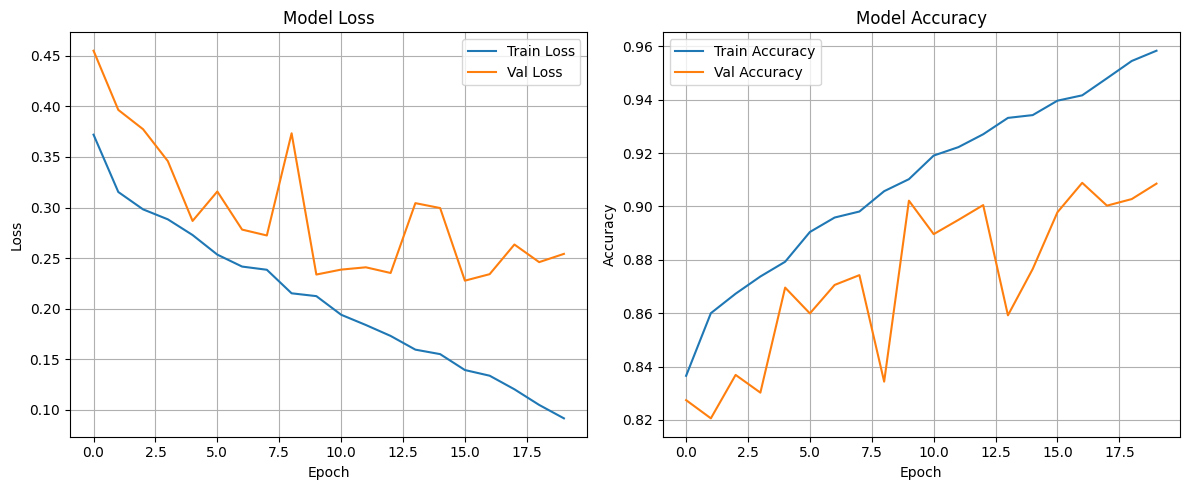

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step


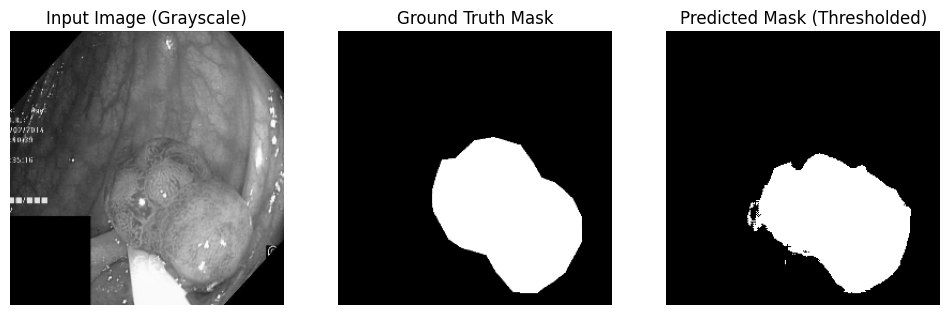

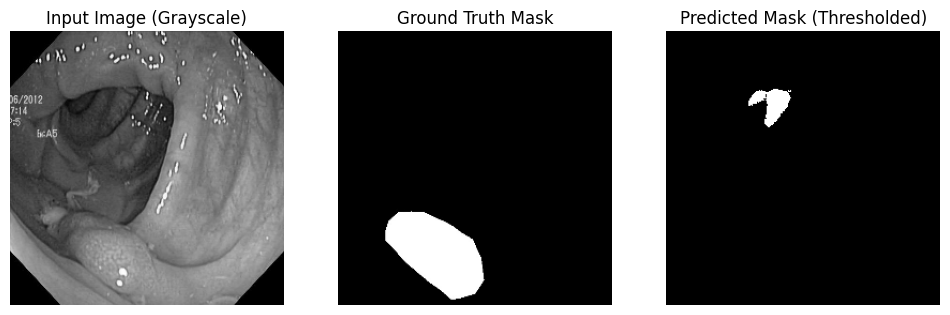

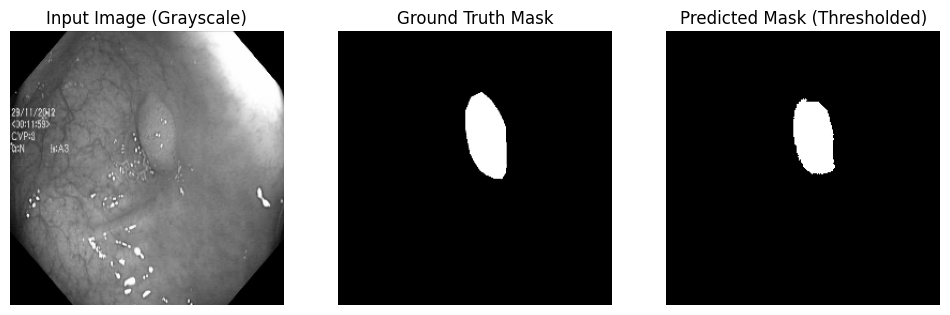

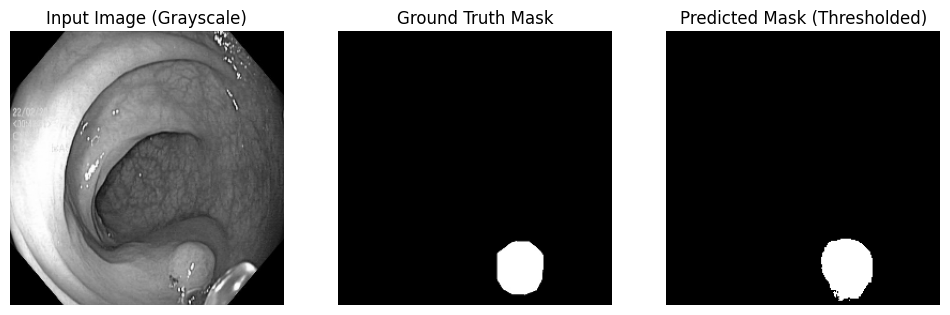

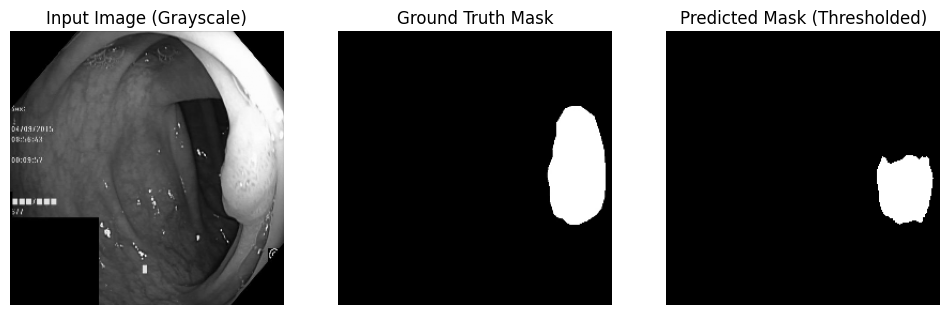

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

# ==========================================
# 1. LOAD VÀ TIỀN XỬ LÝ DỮ LIỆU
# ========================================
zip_path = '/content/kvasir-seg.zip'
extraction_dir = '/content/'

# Giải nén dataset
import zipfile
if not os.path.exists(os.path.join(extraction_dir, 'Kvasir-SEG')):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_dir)
    print(f"Đã giải nén {zip_path} vào {extraction_dir}")
else:
    print(f"Thư mục Kvasir-SEG đã tồn tại ở {extraction_dir}")

image_dir = 'Kvasir-SEG/images'
mask_dir = 'Kvasir-SEG/masks'

def load_kvasir_data(image_dir, mask_dir, img_size=(256, 256)):
    images = []
    masks = []

    # Lấy danh sách tên file
    valid_images = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    for img_name in valid_images:
        img_path = os.path.join(image_dir, img_name)
        mask_path = os.path.join(mask_dir, img_name)

        # Đọc trực tiếp ảnh đầu vào dưới dạng XÁM (Grayscale)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, img_size)
        img = img / 255.0  # Normalize [0, 1]
        img = np.expand_dims(img, axis=-1) # Thêm chiều (256, 256, 1)

        # Đọc mask dưới dạng XÁM
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
        mask = cv2.resize(mask, img_size)
        mask = mask / 255.0  # Normalize [0, 1]
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

print("Đang tải dữ liệu...")
X, Y = load_kvasir_data(image_dir, mask_dir)

# Chia tập dữ liệu (Train 60%, Val 20%, Test 20%)
X_train, X_val_test, Y_train, Y_val_test = train_test_split(X, Y, test_size=0.4, random_state=50)
X_val, X_test, Y_val, Y_test = train_test_split(X_val_test, Y_val_test, test_size=0.5, random_state=50)

print(f"Training set:   {X_train.shape}, {Y_train.shape}")
print(f"Validation set: {X_val.shape}, {Y_val.shape}")
print(f"Test set:       {X_test.shape}, {Y_test.shape}")


# ==========================================
# 2. XÂY DỰNG MÔ HÌNH U-NET (CÓ BATCH NORM)
# ==========================================
def conv_block(inputs, filters):
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    return x

def unet_model(input_size=(256, 256, 1)):
    inputs = tf.keras.layers.Input(input_size)

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 128)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 256)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 512)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = conv_block(p4, 1024)

    # Decoder
    u6 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = conv_block(u6, 512)

    u7 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = conv_block(u7, 256)

    u8 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = conv_block(u8, 128)

    u9 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = conv_block(u9, 64)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)
    return tf.keras.models.Model(inputs=inputs, outputs=outputs)


# ==========================================
# 3. BIÊN DỊCH VÀ HUẤN LUYỆN
# ==========================================
unet = unet_model()

# Dùng Learning Rate thấp (1e-4)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
unet.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

model_checkpoint_dir = 'models'
os.makedirs(model_checkpoint_dir, exist_ok=True)
model_checkpoint_path = os.path.join(model_checkpoint_dir, 'best_unet_model.keras')

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

print("Bắt đầu huấn luyện...")
history = unet.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=3,
    validation_data=(X_val, Y_val),
    callbacks=[checkpoint]
)


# ==========================================
# 4. ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ
# ==========================================
# Đánh giá trên tập test
loss, accuracy = unet.evaluate(X_test, Y_test, batch_size=8)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Vẽ đồ thị Loss & Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ==========================================
# 5. DỰ ĐOÁN VÀ HIỂN THỊ KẾT QUẢ TRỰC QUAN
# ==========================================
preds = unet.predict(X_test[:5])

# Áp dụng Thresholding (0.5) để tạo ảnh nhị phân rõ nét
preds_binary = (preds > 0.5).astype(np.float32)

for i in range(5):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title('Input Image (Grayscale)')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(Y_test[i].squeeze(), cmap='gray')
    plt.title('Ground Truth Mask')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(preds_binary[i].squeeze(), cmap='gray')
    plt.title('Predicted Mask (Thresholded)')
    plt.axis('off')

    plt.show()